In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sb
import statistics as stat
import scipy.stats as st

In [31]:
df = pd.read_csv('taylor_swift_spotify.csv')

In [32]:
df = df[["name", "release_date", "danceability", "popularity", "tempo"]]

In [33]:
df

,name,release_date,danceability,popularity,tempo
0,Welcome To New York (Taylor's Version),2023-10-27,0.757,70,116.998
1,Blank Space (Taylor's Version),2023-10-27,0.733,71,96.057
2,Style (Taylor's Version),2023-10-27,0.511,72,94.868
3,Out Of The Woods (Taylor's Version),2023-10-27,0.545,71,92.021
4,All You Had To Do Was Stay (Taylor's Version),2023-10-27,0.588,70,96.997
...,...,...,...,...,...
525,Our Song,2006-10-24,0.668,76,89.011
526,I'm Only Me When I'm With You,2006-10-24,0.563,62,143.964
527,Invisible,2006-10-24,0.612,58,96.001
528,A Perfectly Good Heart,2006-10-24,0.483,57,156.092


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          530 non-null    object 
 1   release_date  530 non-null    object 
 2   danceability  530 non-null    float64
 3   popularity    530 non-null    int64  
 4   tempo         530 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 20.8+ KB


In [35]:
df.describe()

,danceability,popularity,tempo
count,530.000000,530.000000,530.000000
mean,0.585285,62.777358,122.332311
std,0.113121,15.224702,30.000272
min,0.243000,32.000000,68.097000
25%,0.516000,50.000000,96.939500
50%,0.595500,68.000000,119.030000
75%,0.653000,74.000000,143.934250
max,0.897000,99.000000,208.918000


In [36]:
#Regressão com fórmulas dadas em aula:

In [37]:
dg = df["tempo"]
x = dg.to_numpy()

In [38]:
dg = df["danceability"]
y = dg.to_numpy()

In [42]:
n = 529
somax = sum(x[0:n])
somay = sum(y[0:n])
somaxy = sum(x[0:n] * y[0:n])
somaxquadrado = sum(x[0:n]**2)
somayquadrado = sum(y[0:n]**2)
r = ((n * somaxy) - (somax * somay)) / math.sqrt((n * somaxquadrado - somax**2)*(n * somayquadrado - somay**2))
a = ((n * somaxy) - (somax * somay)) / ((n * somaxquadrado) - (somax**2))
b = (somay / n) - (a * (somax / n))

In [44]:
print("A correlação é igual a", "%.2f" %r, "A equação de reta é Y =", "%.3f" % a, "X +", "%.3f" % b)

A correlação é igual a -0.22 A equação de reta é Y = -0.001 X + 0.685


In [ ]:
#Diagrama de dispersão tempo e danceabilidade e reta de regressão:

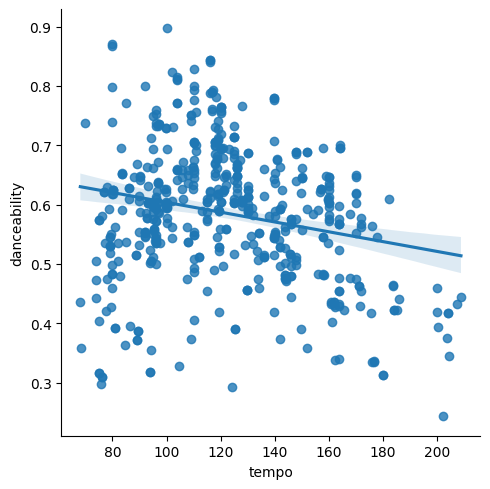

In [41]:
sb.lmplot(x='tempo', y='danceability', data=df)

In [47]:
#Regressão com pacotes prontos do python:

In [45]:
r = df["tempo"].corr(df["danceability"])
print("r =", r)

r = -0.21928947625129824


In [46]:
eq_reta = st.linregress(df["tempo"],df["danceability"])
m = eq_reta.slope
b = eq_reta.intercept
print(f"Equação da reta: y = {eq_reta.slope}x + {eq_reta.intercept}")

Equação da reta: y = -0.0008268691041966792x + 0.6864377143364792
